In [1]:
import pandas as pd
from sklearn import neighbors
from sklearn.metrics import recall_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
training_data1 = pd.read_csv('dados/dados_modelo1.csv') #semanas 1 a 4(ou 5)
training_data2 = pd.read_csv('dados/dados_modelo2.csv') #semanas 1 a 8
training_data3 = pd.read_csv('dados/dados_modelo3.csv') #semanas 1 a 12

# cuidando dos NaN da coluna TempoQ3
for df in [training_data1, training_data2, training_data3]:
    if 'TempoQ3' in df.columns:
        df['TempoQ3'] = df['TempoQ3'].fillna(df['TempoQ3'].mean())


In [3]:
k = 4

def treinar_knn_oversample(df, test_size=0.3, random_state=42, k=k):
    X = df.drop(columns=['Reprovou'])
    y = df['Reprovou']

    # split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # normalizar
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # aplicar SMOTE só no treino
    smote = SMOTE(random_state=random_state)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # treinar KNN
    clf = neighbors.KNeighborsClassifier(n_neighbors=k, weights='distance')
    clf.fit(X_train_res, y_train_res)

    return clf, X_train_res, X_test, y_train_res, y_test


Recall Modelo 1: 0.8508997429305912
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       389
           1       0.15      0.42      0.22        24

    accuracy                           0.83       413
   macro avg       0.55      0.63      0.56       413
weighted avg       0.91      0.83      0.86       413

Recall Modelo 2: 0.8663239074550129
              precision    recall  f1-score   support

           0       0.97      0.87      0.91       389
           1       0.19      0.50      0.27        24

    accuracy                           0.85       413
   macro avg       0.58      0.68      0.59       413
weighted avg       0.92      0.85      0.88       413

Recall Modelo 3: 0.884318766066838
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       389
           1       0.24      0.58      0.34        24

    accuracy                           0.87       413
   macro avg       0.

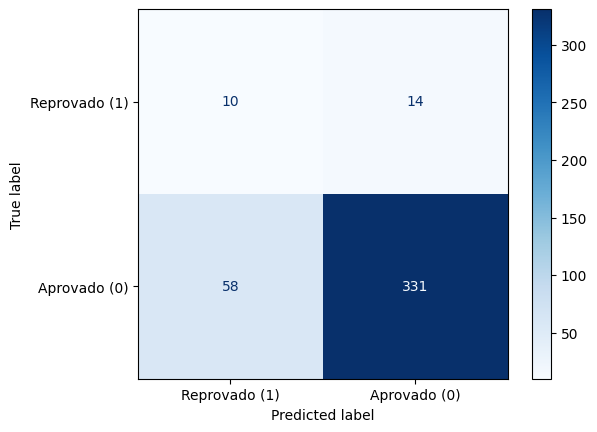

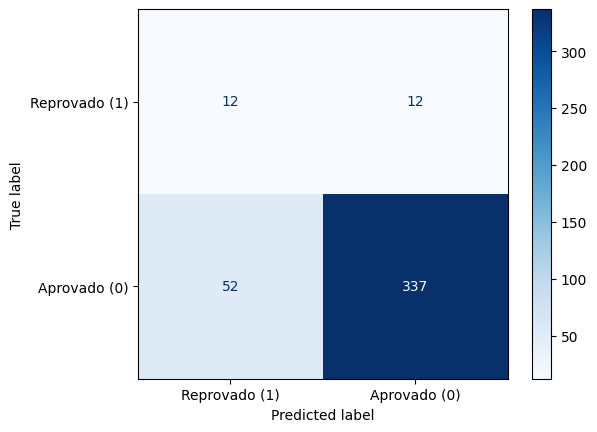

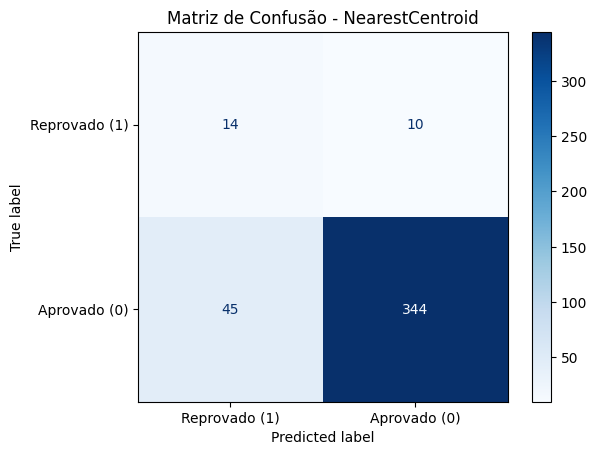

In [4]:
clf1, X1_train_res, X1_test, y1_train_res, y1_test = treinar_knn_oversample(training_data1)
clf2, X2_train_res, X2_test, y2_train_res, y2_test = treinar_knn_oversample(training_data2)
clf3, X3_train_res, X3_test, y3_train_res, y3_test = treinar_knn_oversample(training_data3)

# Avaliação
for i, (clf, X_test, y_test) in enumerate([
    (clf1, X1_test, y1_test),
    (clf2, X2_test, y2_test),
    (clf3, X3_test, y3_test)
], start=1):
    y_pred = clf.predict(X_test)
    print(f"Recall Modelo {i}:", recall_score(y_test, y_pred, pos_label=0))
    print(classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()
